# NextCart Retail Sales Analysis

**Business problem:** NextCart is a (fictional) Thailand-based online retailer. Leadership wants to understand
what is driving revenue and profit performance across regions, product categories, and customer segments,
and whether the current discounting strategy is helping or hurting profitability.

**This notebook covers:**
1. Data quality assessment of the raw sales export
2. Data cleaning (documented, reproducible)
3. SQL business analysis (SQLite)
4. Exploratory visual analysis
5. RFM customer segmentation
6. Key insights & business recommendations

**Note on data:** This dataset is synthetically generated to resemble a real e-commerce sales export
(including realistic data quality issues), since no proprietary company data was available for a
public portfolio piece. The analysis methodology is identical to what would be applied to real data.

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

ACCENT = "#2563EB"
print("Libraries loaded.")

Libraries loaded.


## 1. Load & Inspect Raw Data

In [ ]:
raw = pd.read_csv("data/raw_sales_data.csv")
print(f"Shape: {raw.shape}")
raw.head()

Shape: (4263, 13)


Order ID,Order Date,Customer ID,Customer Name,Segment,Region,Category,Product Name,Quantity,Discount,Sales,Profit,Ship Mode
NC-03806,2023-09-23,CUST-0112,Anan Srisuk,Consumer,Central,Electronics,Laptop,1,0.15,15725.0,5204.63,Standard
NC-03096,2023-07-20,CUST-0380,Theerapat Srisuk,Consumer,Bangkok & Vicinity,Home & Living,Cookware Set,1,0.00,1890.0,596.13,Standard
NC-00391,2023-05-02,CUST-0534,Anan Wongsa,Corporate,SOUTHERN,FASHION,Backpack,1,0.00,990.0,314.20,Standard
NC-02900,2023-03-21,CUST-0210,Krit Phromsri,Consumer,NORTHEASTERN,BEAUTY,Skincare Set,1,0.00,1190.0,370.50,Standard
NC-01599,2023-07-04,CUST-0419,Napat Intharak,Corporate,northeastern,electronics,Headphones,1,0.00,1290.0,352.46,Same Day


## 2. Data Quality Assessment

In [ ]:
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print(f"\nDuplicate rows: {raw.duplicated().sum()}")
print(f"Negative Quantity rows: {(raw['Quantity'] < 0).sum()}")
print(f"\nSample of inconsistent text formatting in 'Region':")
print(raw['Region'].unique()[:8])
print(f"\nSample of mixed date formats in 'Order Date':")
print(raw['Order Date'].sample(5, random_state=1).tolist())

Missing values per column:
Discount    170
Profit      128
dtype: int64

Duplicate rows: 63
Negative Quantity rows: 8

Sample of inconsistent text formatting in 'Region':
<StringArray>
[               'Central',     'Bangkok & Vicinity',           '  SOUTHERN  ',
       '  NORTHEASTERN  ',           'northeastern', '  BANGKOK & VICINITY  ',
           'Northeastern',               'Northern']
Length: 8, dtype: str

Sample of mixed date formats in 'Order Date':
['2023-07-28', '2024-02-08', '2023-07-25', '2023-05-28', '2024-11-26']


**Issues identified:**
- Inconsistent `Order Date` formats (ISO, `DD/MM/YYYY`, and timestamped strings mixed together)
- Inconsistent text casing/whitespace in `Region` and `Category` (e.g. `"SOUTHERN"`, `"  Central  "`, `"northern"`)
- Missing values in `Discount` and `Profit`
- Duplicate order rows
- A handful of negative `Quantity` values (data entry errors)

## 3. Data Cleaning

In [ ]:
df = raw.copy()
start_rows = len(df)

# Standardize dates (try multiple known formats)
def parse_date(val):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%Y-%m-%d %H:%M:%S"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(val, errors="coerce")

df["Order Date"] = df["Order Date"].apply(parse_date)
df = df.dropna(subset=["Order Date"])

# Standardize text fields
for col in ["Region", "Category", "Segment", "Ship Mode"]:
    df[col] = df[col].astype(str).str.strip().str.title()

# Remove duplicates and invalid rows
df = df.drop_duplicates()
df = df[df["Quantity"] > 0]

# Impute missing Discount as 0 (no discount applied)
df["Discount"] = df["Discount"].fillna(0)

# Impute missing Profit using category-average margin
category_margin = (
    df.dropna(subset=["Profit"])
    .assign(margin=lambda x: x["Profit"] / x["Sales"])
    .groupby("Category")["margin"].mean()
)
def fill_profit(row):
    if pd.isna(row["Profit"]):
        m = category_margin.get(row["Category"], category_margin.mean())
        return round(row["Sales"] * m, 2)
    return row["Profit"]
df["Profit"] = df.apply(fill_profit, axis=1)

df["Order Date"] = pd.to_datetime(df["Order Date"]).dt.date
df = df.sort_values("Order Date").reset_index(drop=True)

print(f"Rows before cleaning: {start_rows}")
print(f"Rows after cleaning:  {len(df)}")
print(f"Remaining missing values: {df.isna().sum().sum()}")

df.to_csv("data/cleaned_sales_data_nb.csv", index=False)

Rows before cleaning: 4263
Rows after cleaning:  4192
Remaining missing values: 0


## 4. SQL Business Analysis (SQLite)

In [ ]:
conn = sqlite3.connect(":memory:")
df_sql = df.copy()
df_sql["Order Date"] = pd.to_datetime(df_sql["Order Date"])
df_sql.to_sql("sales", conn, index=False, if_exists="replace")
print("Loaded", len(df_sql), "rows into in-memory SQLite table `sales`.")

Loaded 4192 rows into in-memory SQLite table `sales`.


**Q: What does the monthly revenue & profit trend look like?**

In [ ]:
monthly_sql = pd.read_sql_query('''
    SELECT strftime('%Y-%m', "Order Date") AS order_month,
           ROUND(SUM(Sales), 2) AS total_sales,
           ROUND(SUM(Profit), 2) AS total_profit,
           COUNT(DISTINCT "Order ID") AS num_orders
    FROM sales
    GROUP BY order_month
    ORDER BY order_month
''', conn)
monthly_sql.head(12)

order_month,total_sales,total_profit,num_orders
2023-01,43573.5,12907.16,16
2023-02,141755.5,46419.15,66
2023-03,302724.0,97228.04,100
2023-04,410073.5,135005.57,138
2023-05,468236.5,151963.24,155
2023-06,562142.0,180149.01,185
2023-07,766711.5,225119.33,210
2023-08,498797.5,163690.79,206
2023-09,690310.0,227522.96,220
2023-10,783873.5,263155.06,254


**Q: Which region and category combination drives the most profit, and at what margin?**

In [ ]:
region_sql = pd.read_sql_query('''
    SELECT Region,
           ROUND(SUM(Sales), 2) AS total_sales,
           ROUND(SUM(Profit), 2) AS total_profit,
           ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS profit_margin_pct
    FROM sales
    GROUP BY Region
    ORDER BY total_sales DESC
''', conn)
region_sql

Region,total_sales,total_profit,profit_margin_pct
Bangkok & Vicinity,5178299.0,1644552.43,31.76
Northeastern,2273504.0,716882.39,31.53
Central,2115919.5,694448.41,32.82
Northern,1817947.0,601559.66,33.09
Southern,1692230.5,512776.16,30.30


**Q: Is discounting actually paying for itself?**

In [ ]:
discount_sql = pd.read_sql_query('''
    SELECT
        CASE WHEN Discount = 0 THEN 'No Discount'
             WHEN Discount <= 0.10 THEN 'Low (1-10%)'
             ELSE 'High (>10%)' END AS discount_band,
        COUNT(*) AS num_orders,
        ROUND(AVG(Sales), 2) AS avg_order_value,
        ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS profit_margin_pct
    FROM sales
    GROUP BY discount_band
    ORDER BY profit_margin_pct DESC
''', conn)
discount_sql

discount_band,num_orders,avg_order_value,profit_margin_pct
No Discount,2617,3223.07,34.39
Low (1-10%),1053,3103.69,29.91
High (>10%),522,2634.00,21.21


> **Finding:** Profit margin drops from **34.4%** (no discount) to **21.2%** (discounts above 10%).
> The discount strategy is increasing order volume but eroding overall profitability faster than it's
> generating incremental revenue. See Section 6 for the full recommendation.

## 5. Exploratory Visual Analysis

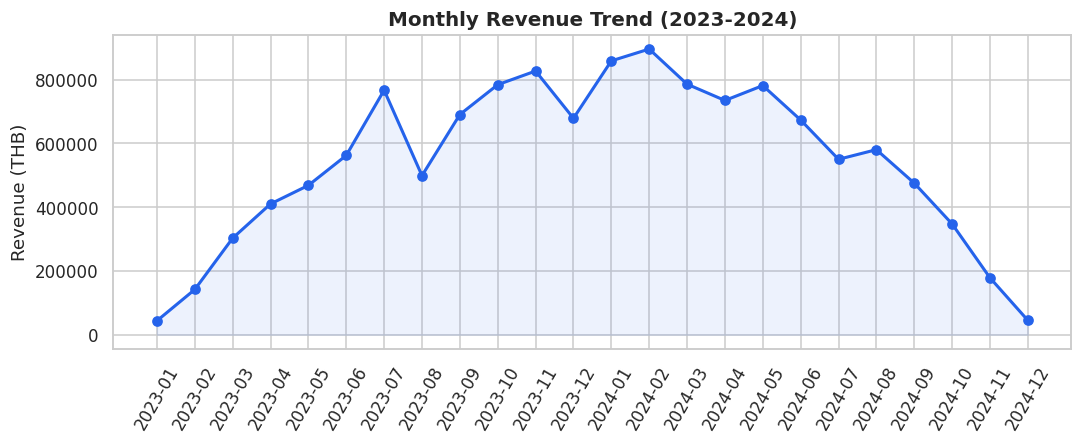

In [ ]:
monthly = df.groupby(pd.to_datetime(df["Order Date"]).dt.to_period("M").astype(str))["Sales"].sum().reset_index()
monthly.columns = ["order_month", "Sales"]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(monthly["order_month"], monthly["Sales"], marker="o", color=ACCENT, linewidth=2)
ax.fill_between(range(len(monthly)), monthly["Sales"], alpha=0.08, color=ACCENT)
ax.set_title("Monthly Revenue Trend (2023-2024)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (THB)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

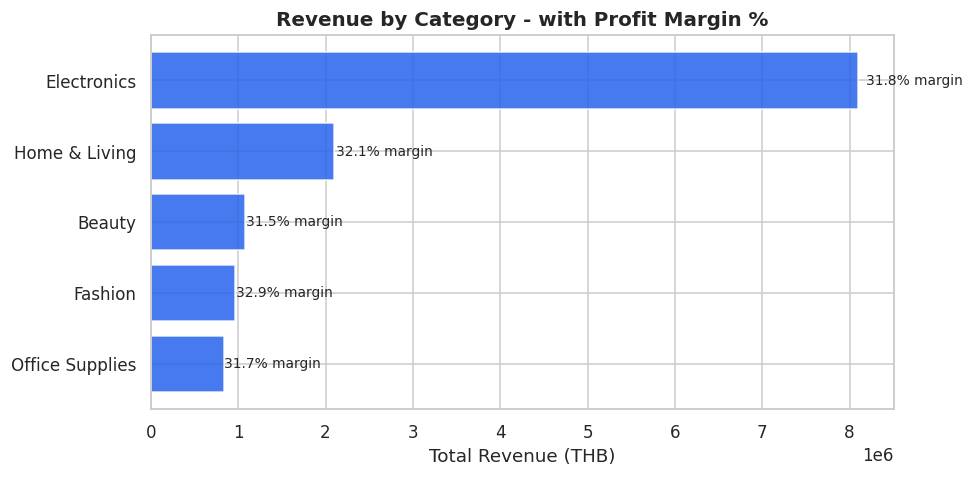

In [ ]:
cat = df.groupby("Category").agg(total_sales=("Sales","sum"), total_profit=("Profit","sum")).reset_index()
cat["margin_pct"] = (cat["total_profit"] / cat["total_sales"] * 100).round(1)
cat = cat.sort_values("total_sales")

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(cat["Category"], cat["total_sales"], color=ACCENT, alpha=0.85)
ax.set_title("Revenue by Category - with Profit Margin %", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Revenue (THB)")
for bar, margin in zip(bars, cat["margin_pct"]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, f"{margin}% margin", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. RFM Customer Segmentation

RFM scores each customer on **Recency** (days since last order), **Frequency** (number of orders),
and **Monetary** value (total spend), then buckets them into actionable segments — a standard technique
for prioritizing retention and loyalty efforts.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
).reset_index()

rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment_customer(row):
    if row["RFM_total"] >= 10: return "Champions"
    elif row["RFM_total"] >= 8: return "Loyal Customers"
    elif row["RFM_total"] >= 6: return "Potential Loyalists"
    elif row["RFM_total"] >= 4: return "At Risk"
    return "Lost / Inactive"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

seg_summary = rfm.groupby("Segment").agg(
    num_customers=("Customer ID","count"),
    avg_monetary=("Monetary","mean")
).round(0).sort_values("avg_monetary", ascending=False).reset_index()
seg_summary

Segment,num_customers,avg_monetary
Champions,236,27503.0
Loyal Customers,255,15118.0
Potential Loyalists,232,8688.0
At Risk,138,4202.0
Lost / Inactive,79,1730.0


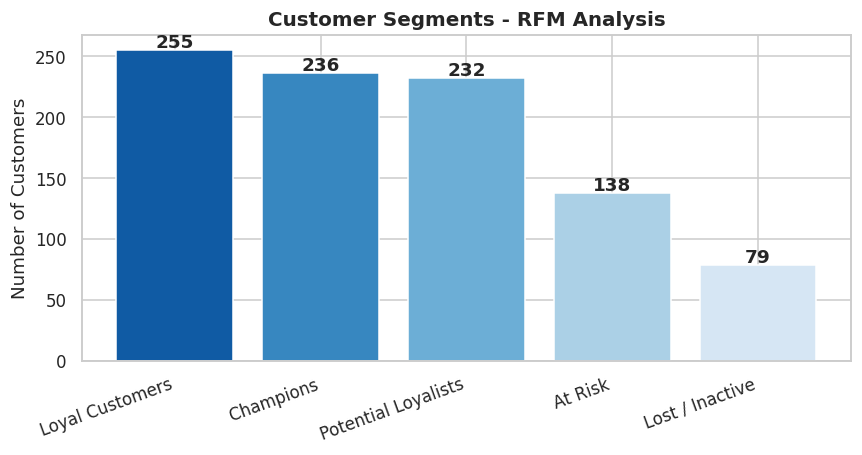

In [ ]:
seg_order = seg_summary.sort_values("num_customers", ascending=False)
colors5 = sns.color_palette("Blues_r", n_colors=len(seg_order))

fig, ax = plt.subplots(figsize=(8, 4.3))
bars = ax.bar(seg_order["Segment"], seg_order["num_customers"], color=colors5)
ax.set_title("Customer Segments - RFM Analysis", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2, int(h), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Key Insights & Business Recommendations

**1. Discounting is eroding margin faster than it's driving volume.**
Orders with no discount run a 34.4% margin vs. 21.2% for discounts above 10%. Recommendation: cap
standard discounts at 10% and reserve deeper discounts for clearing aged inventory only, with margin
impact tracked monthly.

**2. Electronics drives revenue, but margin is more evenly spread.**
Electronics is the largest category by revenue, but Home & Living and Fashion carry comparable or
better margins. Recommendation: feature higher-margin categories more prominently in cross-sell and
bundle promotions rather than relying on Electronics alone.

**3. Bangkok & Vicinity is the clear revenue anchor, but margins are consistent nationwide.**
All five regions post profit margins within a tight 30-33% band — regional performance gaps are about
order volume, not regional pricing/cost inefficiency. Recommendation: growth investment should prioritize
expanding order volume in underweighted regions (Southern, Northern) rather than adjusting regional pricing.

**4. ~22% of customers ("Champions" + "Loyal Customers") generate a disproportionate share of revenue.**
Recommendation: launch a tiered loyalty program targeting these ~490 customers, and build a
win-back campaign for the "At Risk" segment (138 customers) before they lapse into "Lost / Inactive."

**5. Revenue softened notably in Q4 2024** relative to the same period in 2023.
Recommendation: this is worth investigating against marketing spend, inventory stockouts, or competitive
activity in the next planning cycle — flagged here as a question for stakeholders, not a conclusion the
data alone can answer.

---
*Full SQL queries: `sql/sales_analysis.sql` · Cleaning log: `data/cleaning_log.txt` · Interactive
dashboard: `dashboard.html`*